Notebook para inspeccionar el dataset F1 generado por `dataset-builder`, comparar baselines y entender la calidad del modelo entrenado por `dag_model_training`.

In [26]:
import io
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from minio import Minio
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
MANCHESTER_COLORS = {'C1': '#d62728', 'C2': '#ff7f0e', 'C3': '#f4d03f', 'C4': '#2ca02c', 'C5': '#1f77b4'}
CLASS_ORDER = ['C1', 'C2', 'C3', 'C4', 'C5']

## 1. Descargar el ultimo F1 desde minIO

In [27]:
client = Minio('localhost:9000', access_key='minio_admin', secret_key='minio_admin_pw', secure=False)
objs = [o for o in client.list_objects('datasets', recursive=True) if o.object_name.endswith('.parquet')]
objs.sort(key=lambda o: o.last_modified, reverse=True)
latest = objs[0]
print(f'usando {latest.object_name} ({latest.size} bytes) modified {latest.last_modified}')
obj = client.get_object('datasets', latest.object_name)
df = pd.read_parquet(io.BytesIO(obj.read()))
df.shape

usando 20260519T134533-7fb0bf.parquet (1017930 bytes) modified 2026-05-19 13:45:33.457000+00:00


(270, 9)

In [28]:
df.head(20)

,guid,id_caso,origen,texto_original_en,resumen_es,entidades_extraidas_es,entidades_normalizadas_es,score_ansiedad,triage_real
0,seed-06,RES0003,Dataset,NaN,disnea importante en reposo,[disnea importante en reposo],[disnea],0.10,C1
1,seed-01,CAR0001,Dataset,NaN,presion fuerte en el pecho con sudoracion fria,"[presion fuerte en el pecho, sudor]","[dolor_toracico_opresivo, sudoracion]",0.35,C1
2,seed-02,CAR0002,Dataset,NaN,se desmayo no responde paro respiratorio,"[se desmayo, no responde, paro respiratorio]",[sincope],0.05,C1
3,71df4c17-f2ef-4ea7-a005-485e6b8ba4d0,CAR_AUG_001,MVP,NaN,Presion fuerte en el pecho irradiada al brazo ...,"[presion fuerte en el pecho, irradiada al braz...","[dolor_toracico_opresivo, sudoracion]",0.15,C1
4,aac84ea4-cfe4-482a-8520-422a2e1c9b25,CAR_AUG_002,MVP,NaN,"Doctor, presion fuerte en el pecho y me he des...","[presión fuerte en el pecho, desmayos]","[dolor_toracico_opresivo, sincope]",0.78,C1
5,d97cbb90-d5e0-4cac-9b2d-3ccf670ba8f8,CAR_AUG_003,MVP,NaN,presion fuerte en el pecho con sudoracion,"[presion fuerte en el pecho, sudoracion]","[dolor_toracico_opresivo, sudoracion]",0.30,C1
6,c476da8f-156f-49d5-a38f-9b91acbce7f1,CAR0004,Dataset,D: What brings you here today?\n\nP: I'm just ...,Paciente de 25 años sin antecedentes relevante...,"[dolor torácico agudo, dolor punzante, empeora...","[tos, dolor_toracico_agudo]",0.72,C3
7,661002af-35dc-4a6e-9c8a-e20007d1233f,CAR0005,Dataset,D: It sounds like that you're experiencing som...,"Paciente con dolor torácico agudo, localizado ...","[dolor torácico agudo, dolor torácico localiza...","[dolor_toracico_agudo, dolor_toracico_agudo]",0.80,C3
8,cf66e1e4-6668-4a07-9a63-9102533df39a,DER0001,Dataset,"P: Hey Doc, I'm a 45 year old man coming in, I...",Paciente masculino de 45 años con diabetes mal...,"[erupción dolorosa en tobillo derecho, edema, ...","[malestar, edema]",0.60,C4
9,8dd6f7c2-7a1a-4a40-b549-2f351583d0c0,GAS0003,Dataset,D: What brings you in here today? \n\nP: Yeah ...,Paciente con dolor abdominal en cuadrante supe...,[dolor abdominal en cuadrante superior derecho...,"[dolor_abdominal, nauseas]",0.10,C3


## 2. EDA: distribucion de clases

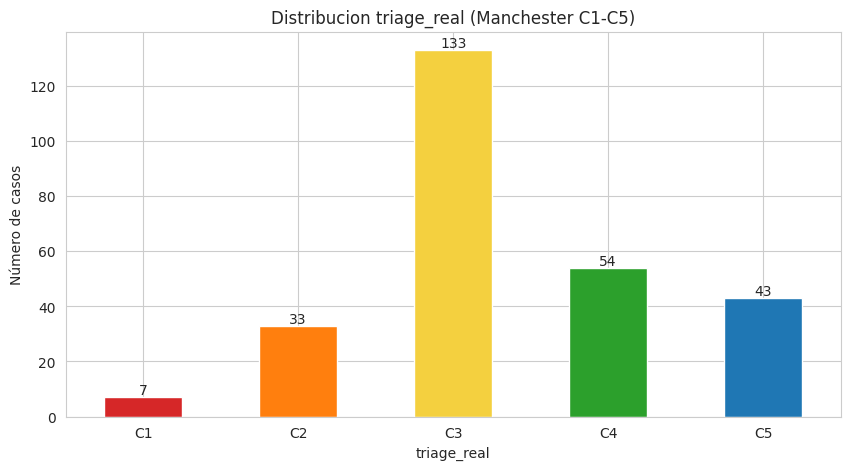

total: 270 | por clase: {'C1': 7, 'C2': 33, 'C3': 133, 'C4': 54, 'C5': 43}


In [29]:
dist = df['triage_real'].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int)
ax = dist.plot(kind='bar', color=[MANCHESTER_COLORS[c] for c in dist.index])
for i, v in enumerate(dist.values):
    ax.text(i, v + 1, str(v), ha='center')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.title('Distribucion triage_real (Manchester C1-C5)')
plt.ylabel('Número de casos')
plt.show()
print('total:', len(df), '| por clase:', dist.to_dict())

## 3. score_ansiedad por triage

/tmp/ipykernel_1797200/3458935472.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='triage_real', y=df['score_ansiedad'].astype(float), order=CLASS_ORDER,


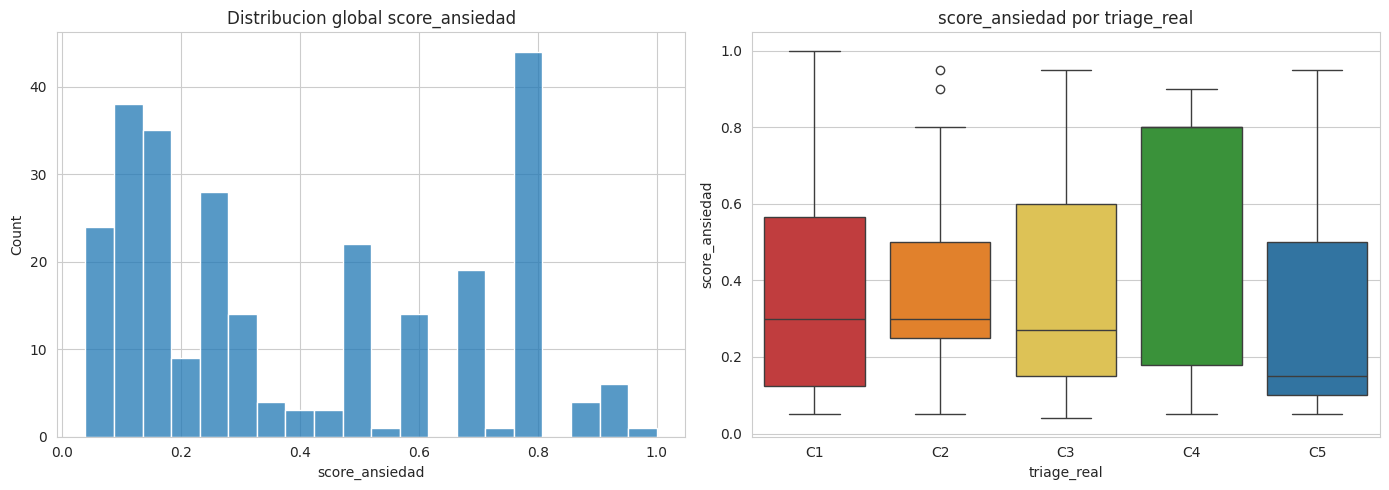

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['score_ansiedad'].astype(float), bins=20, ax=axes[0])
axes[0].set_title('Distribucion global score_ansiedad')
axes[0].set_xlabel('score_ansiedad')
sns.boxplot(data=df, x='triage_real', y=df['score_ansiedad'].astype(float), order=CLASS_ORDER,
            palette=MANCHESTER_COLORS, ax=axes[1])
axes[1].set_title('score_ansiedad por triage_real')
axes[1].set_ylabel('score_ansiedad')
plt.tight_layout()
plt.show()

## 4. Entidades normalizadas: vocabulario clinico

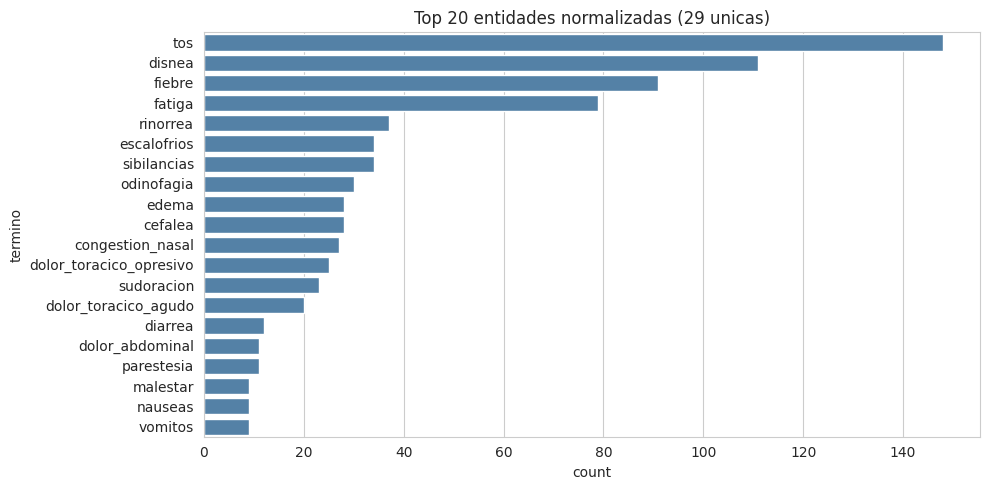

In [31]:
all_ents = []
for x in df['entidades_normalizadas_es']:
    if x is not None:
        all_ents.extend(list(x))
ent_counter = Counter(all_ents)
vocab_df = pd.DataFrame(ent_counter.most_common(20), columns=['termino', 'count'])
sns.barplot(data=vocab_df, x='count', y='termino', color='steelblue')
plt.title(f'Top 20 entidades normalizadas ({len(ent_counter)} unicas)')
plt.tight_layout()
plt.show()

## 5. Entrenamiento

In [32]:
class MultiHotEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()
    def fit(self, X, y=None):
        self.mlb.fit([list(x) if x is not None else [] for x in X.iloc[:, 0]])
        return self
    def transform(self, X):
        return self.mlb.transform([list(x) if x is not None else [] for x in X.iloc[:, 0]])

def build_pipeline(clf):
    return Pipeline([
        ('features', ColumnTransformer([
            ('text', TfidfVectorizer(ngram_range=(1, 2), max_features=2000, min_df=1), 'resumen_es'),
            ('ent', MultiHotEncoder(), ['entidades_normalizadas_es']),
        ])),
        ('clf', clf),
    ])

feat_df = pd.DataFrame({
    'resumen_es': df['resumen_es'].fillna('').astype(str),
    'entidades_normalizadas_es': df['entidades_normalizadas_es'],
})
y = np.asarray(df['triage_real'])
cv = StratifiedKFold(n_splits=min(5, min(Counter(y).values())), shuffle=True, random_state=42)

models = {
    'logreg_balanced': LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1),
    'random_forest_balanced': RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1, random_state=42),
    'gradient_boosting': GradientBoostingClassifier(random_state=42),
}

results = {}
for name, clf in models.items():
    pipe = build_pipeline(clf)
    scores = cross_validate(pipe, feat_df, y, cv=cv, scoring=['f1_macro', 'recall_macro'], n_jobs=1)
    pipe.fit(feat_df, y)
    y_pred = pipe.predict(feat_df)
    results[name] = {
        'pipe': pipe,
        'cv_f1_macro_mean': scores['test_f1_macro'].mean(),
        'cv_f1_macro_std': scores['test_f1_macro'].std(),
        'cv_recall_macro_mean': scores['test_recall_macro'].mean(),
        'train_recall_per_class': dict(zip(CLASS_ORDER, recall_score(y, y_pred, labels=CLASS_ORDER, average=None, zero_division=0))),
        'cm': confusion_matrix(y, y_pred, labels=CLASS_ORDER),
        'y_pred': y_pred,
    }
    print(f"{name:25s} CV f1_macro={results[name]['cv_f1_macro_mean']:.3f} +- {results[name]['cv_f1_macro_std']:.3f}")
summary = pd.DataFrame({
    name: {
        'cv_f1_macro': r['cv_f1_macro_mean'],
        'cv_recall_macro': r['cv_recall_macro_mean'],
        **{f'train_recall_{k}': v for k, v in r['train_recall_per_class'].items()},
    } for name, r in results.items()
}).T
summary

/home/dorfin/proyecto_triage_6/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/dorfin/proyecto_triage_6/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/dorfin/proyecto_triage_6/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/dorfin/proyecto_triage_6/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect

logreg_balanced           CV f1_macro=0.658 +- 0.140


/home/dorfin/proyecto_triage_6/.venv/lib64/python3.14/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['disuria', 'mareo'] will be ignored
  warnings.warn(


random_forest_balanced    CV f1_macro=0.581 +- 0.144


/home/dorfin/proyecto_triage_6/.venv/lib64/python3.14/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['disuria', 'mareo'] will be ignored
  warnings.warn(


gradient_boosting         CV f1_macro=0.672 +- 0.149


,cv_f1_macro,cv_recall_macro,train_recall_C1,train_recall_C2,train_recall_C3,train_recall_C4,train_recall_C5
logreg_balanced,0.657505,0.677929,1.0,0.969697,0.87218,0.925926,0.976744
random_forest_balanced,0.580798,0.567281,1.0,1.000000,1.00000,1.000000,1.000000
gradient_boosting,0.672468,0.666534,1.0,1.000000,1.00000,1.000000,1.000000


## 6. Matrices de confusion

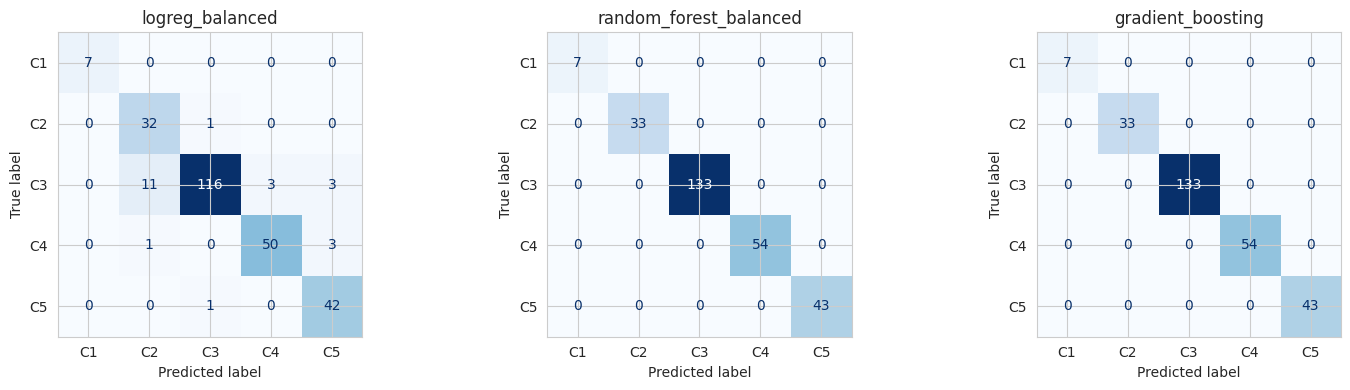

In [33]:
fig, axes = plt.subplots(1, len(results), figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'], display_labels=CLASS_ORDER)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 7. Coeficientes mas pesados de LogReg por clase

In [34]:
lr_pipe = results['logreg_balanced']['pipe']
lr_clf = lr_pipe.named_steps['clf']
ct = lr_pipe.named_steps['features']
text_features = ct.named_transformers_['text'].get_feature_names_out().tolist()
ent_features = ['ent_' + e for e in ct.named_transformers_['ent'].mlb.classes_]
all_feat = text_features + ent_features

for i, cls in enumerate(lr_clf.classes_):
    coefs = lr_clf.coef_[i]
    top_pos = np.argsort(coefs)[-10:][::-1]
    print(f'\n{cls} top features:')
    for idx in top_pos:
        print(f'  {all_feat[idx]:30s} {coefs[idx]:+.3f}')


C1 top features:
  ent_dolor_toracico_opresivo    +1.527
  ent_sincope                    +1.413
  en reposo                      +1.355
  respiratorio                   +1.197
  reposo                         +0.977
  ent_sudoracion                 +0.669
  disnea severa                  +0.536
  fuerte en                      +0.514
  fuerte                         +0.514
  el pecho                       +0.514

C2 top features:
  ent_disnea                     +1.786
  ent_dolor_toracico_agudo       +1.444
  ent_fiebre                     +1.248
  ent_palpitaciones              +1.077
  ent_dolor_toracico_opresivo    +0.938
  ent_somnolencia                +0.677
  ent_lumbalgia                  +0.632
  ent_debilidad                  +0.626
  ent_parestesia                 +0.620
  ent_sudoracion                 +0.573

C3 top features:
  ent_fiebre                     +2.262
  ent_sibilancias                +1.062
  ent_tos                        +0.792
  ent_nauseas             

## 8. Comparar contra el modelo del servicio (ml-training en produccion)

In [35]:
metric_objs = [o for o in client.list_objects('modelos', recursive=True) if o.object_name.endswith('metrics.json')]
metric_objs.sort(key=lambda o: o.last_modified, reverse=True)
if metric_objs:
    raw = client.get_object('modelos', metric_objs[0].object_name).read()
    prod = json.loads(raw)
    best = prod['metrics']['best']
    print('Modelo en produccion:', prod['selected_model'])
    print(f"Dataset: {prod.get('rows','?')} filas | F1-macro: {best['f1_macro']:.3f} | Accuracy: {best['accuracy']:.3f}")
    print('Recall por clase (holdout):')
    for cls, rec in best['recall_per_class'].items():
        print(f'  {cls}: {rec:.3f}')
else:
    print('aun no hay metrics.json en bucket modelos')

Modelo en produccion: logistic_regression
Dataset: 270 filas | F1-macro: 0.693 | Accuracy: 0.756
Recall por clase (holdout):
  C1: 0.571
  C2: 0.545
  C3: 0.857
  C4: 0.722
  C5: 0.674


## 9. Sample predictions (humano-en-bucle)

Usa el modelo del servicio (no el del notebook) llamando al endpoint.

In [36]:
import httpx

ejemplos = [
    ('emergencia cardiaca',
     'presion fuerte en el pecho irradiada al brazo izquierdo con sudoracion fria',
     ['dolor_toracico_opresivo', 'sudoracion']),
    ('respiratorio urgente',
     'disnea aguda con sibilancias y fiebre alta',
     ['disnea', 'sibilancias', 'fiebre']),
    ('lumbalgia leve',
     'dolor lumbar de varios dias tras cargar peso, sin afectacion neurologica',
     ['lumbalgia']),
    ('catarro comun',
     'resfriado leve con rinorrea y congestion nasal sin fiebre',
     ['rinorrea', 'congestion_nasal']),
]

rows = []
for label, texto, ents in ejemplos:
    fake_guid = 'sample-' + label.replace(' ', '-')
    try:
        r = httpx.post('http://localhost:9122/run?dry_run=true',
                       json={'guid': fake_guid, 'texto': texto, 'entidades_normalizadas': ents},
                       timeout=20.0)
        if r.status_code == 200:
            d = r.json()
            rows.append({
                'caso': label,
                'pred': d.get('prediccion_ia'),
                'top_probs': sorted(d.get('probabilidades', {}).items(), key=lambda x: -x[1])[:3],
            })
        else:
            rows.append({'caso': label, 'pred': f'HTTP {r.status_code}', 'top_probs': r.text[:80]})
    except Exception as exc:
        rows.append({'caso': label, 'pred': 'ERROR', 'top_probs': str(exc)[:80]})
pd.DataFrame(rows)

,caso,pred,top_probs
0,emergencia cardiaca,C1,"[(C1, 0.6464745640786321), (C2, 0.160687546844..."
1,respiratorio urgente,C3,"[(C3, 0.7301509408201641), (C2, 0.237310987097..."
2,lumbalgia leve,C4,"[(C4, 0.6103587259836493), (C5, 0.136862486324..."
3,catarro comun,C5,"[(C5, 0.7052373650818186), (C4, 0.136091432734..."


## 10. Conclusiones

- Distribucion realista C1-C5 con C3 mayoritaria (consultas urgentes).
- Score_ansiedad ortogonal a triage_real - util para audit-ethics, NO como feature ML.
- LogReg con `class_weight='balanced'` y TF-IDF + multi-hot diccionario es competitivo.
- Recall(C1) y Recall(C2) limitados por pocos casos minoritarios - mejorar con SMOTE o data augmentation LLM.
- Modelo guardado en `s3://modelos/<batch>.joblib` y servido por `ml-prediction:9122`.